# Crypto Perpetuals: Label Engineering

Every model in this case study is trained to predict the label defined here, so an error in
it is silent where it is made and reaches every metric and every backtest after it. This
notebook fixes the execution convention, proves each labelled row has a complete forward
window, measures how much independent information those rows carry, establishes the floor a
feature has to clear, and writes the files stage 03 reads.

## Learning objectives

- Move a provider's bar-open timestamps onto the clock at which each bar is actually known,
  and express a forward return from that boundary
- Assert, rather than describe, that every labelled row has a gap-free window inside one
  symbol, and account for every row that carries no label
- Seal a diagnostic on the label's endpoint rather than on its observation date
- Price the overlap in a multi-period label, both as decay and as an effective row count
- Establish the baseline a feature has to clear, under a standard error that prices in that
  overlap

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads the Binance premium-index and perpetual bar series through
`load_crypto_premium()` and `load_crypto_perps()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the label set, the horizons and the holdout boundary.
Writes `labels/fwd_ret_8h.parquet`, `labels/fwd_ret_24h.parquet`,
`labels/fwd_dir_8h.parquet` and `labels/fwd_dir_8h_3c.parquet`, each with a `.digest.json`
sidecar beside it. `03_financial_features.py` reads whichever label is `labels.primary`.

In [1]:
"""Crypto Perps Funding: Label Engineering."""

import warnings
from datetime import UTC, datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_crypto_perps, load_crypto_premium
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "crypto_perps_funding"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

Both parameters are unset by default, and both are read below. `START_DATE` trims the history
to a later start; `MAX_SYMBOLS` keeps only the first symbols in alphabetical order. Either one
shortens a run, at the cost of a thinner cross-section for the rank correlation in Section G.

In [2]:
MAX_SYMBOLS = None
START_DATE = None

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A horizon
or a boundary typed into a cell is a second copy of a value the rest of the pipeline reads
from the file, and the two drift apart the first time either is edited.

`resolve_label_horizon` prefers an explicit `labels.horizons` entry and falls back to the
cross-validation buffer. The two fields are separate, because the gap that keeps folds
independent need not equal the horizon an outcome resolves over; here they coincide, and both
are declared in hours. Dividing by the length of a bar turns each into a number of settlement
periods, which is the unit a shift counts in.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
BAR_HOURS = 8

PRIMARY_LABEL = setup["labels"]["primary"]
VARIANT_LABEL = setup["labels"]["variants"][0]
RETURN_LABELS = [PRIMARY_LABEL, VARIANT_LABEL]
BINARY_LABEL, THREE_CLASS_LABEL = setup["labels"]["variants"][1:]
ALL_LABELS = [*RETURN_LABELS, BINARY_LABEL, THREE_CLASS_LABEL]
HORIZONS = {
    name: int(resolve_label_horizon(CASE_STUDY_ID, name, setup).rstrip("Hh")) // BAR_HOURS
    for name in RETURN_LABELS
}
window = setup["evaluation"]
HOLDOUT_START = datetime.fromisoformat(window["holdout_start"]).replace(tzinfo=UTC)
WINDOW_END = datetime.fromisoformat(window["holdout_end"]).replace(tzinfo=UTC) + timedelta(days=1)

print(f"Labels: {ALL_LABELS}, primary {PRIMARY_LABEL}, horizons {HORIZONS} settlement periods")
print(f"Holdout opens {HOLDOUT_START.date()}, and seals the label endpoint")

Labels: ['fwd_ret_8h', 'fwd_ret_24h', 'fwd_dir_8h', 'fwd_dir_8h_3c'], primary fwd_ret_8h, horizons {'fwd_ret_8h': 1, 'fwd_ret_24h': 3} settlement periods
Holdout opens 2024-01-01, and seals the label endpoint


## A. The learning task

The hypothesis is that a perpetual's premium over spot is a crowding measure that mean
reverts. When the premium index sits far above its own recent level, longs are paying to hold
the contract, and the perpetual price is expected to give ground relative to the rest of the
universe. The label is therefore a forward price return on the perpetual itself, ranked
across symbols rather than judged in isolation.

The decision cadence comes from the market's own settlement rhythm. Binance settles funding
every eight hours, the premium index is published on that grid, and a decision can be acted
on at each settlement, which fixes the primary horizon at one period. The variant asks
whether the same relationship pays over three periods. That is a question about how long the
crowding takes to unwind, and about how often a strategy would have to trade, rather than a
second hypothesis.

One thing the label is not: the funding payment. The premium index predicts funding without
being it, because the realized rate adds an interest component and exchange clamps. A
strategy that collects funding is a separate construction on the funding-rate series, and
this label cannot measure it.

## B. Preparation before the label

A forward window is meaningful only on a series whose timestamps mean what the label assumes.
Binance stamps each row with the time its bar **opened**, so a row stamped midnight reports a
premium and a close that nobody knows until eight hours later. Both series are therefore
advanced by one bar length before anything is joined, shifted or filtered, and the resulting
`timestamp` is the boundary at which the completed bar's premium and its close are jointly
available. Building the label on the provider's clock would pair a predictor with a return
that had already happened.

No eligibility filter runs before the shift, and that ordering matters: dropping rows first
makes a shift count surviving rows, so the horizon stops being measured in settlement periods
and the window silently spans whatever was removed. The universe is a fixed nineteen-symbol
research panel rather than a point-in-time liquidity ranking, a selection bias
`01_feasibility_analysis` documents and this notebook inherits.

In [4]:
available_at = (pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).alias("timestamp")
in_window = pl.col("timestamp") < WINDOW_END

premium = load_crypto_premium(frequency="8h", start_date=START_DATE).with_columns(available_at)
perps = load_crypto_perps(frequency="8h", start_date=START_DATE).with_columns(available_at)
premium, perps = premium.filter(in_window), perps.filter(in_window)
if MAX_SYMBOLS is not None:
    keep = sorted(premium["symbol"].unique().to_list())[:MAX_SYMBOLS]
    premium = premium.filter(pl.col("symbol").is_in(keep))
    perps = perps.filter(pl.col("symbol").is_in(keep))

The settlement grid is asserted rather than assumed. The labels below are built by comparing
a shifted timestamp against `t` plus a horizon, so a stamp off the grid would null a label
that is in fact well defined. Duplicate keys are checked before the join and not after,
because a duplicated key multiplies rows and every shift past it is then measured across the
wrong pair of bars.

The join keeps the premium series as the spine, so a symbol-period with a predictor and no
perpetual bar keeps its row, with a null price and a null label. Section D counts those rows.

In [5]:
for name, frame in (("premium", premium), ("perps", perps)):
    hours = frame["timestamp"].dt.hour().unique().sort().to_list()
    assert hours == [0, BAR_HOURS, 2 * BAR_HOURS], f"{name}: off-grid stamps {hours}"
    assert frame.select(["timestamp", "symbol"]).is_duplicated().sum() == 0, f"{name}: repeated key"

prices = premium.join(
    perps.select(["timestamp", "symbol", "close"]), on=["timestamp", "symbol"], how="left"
).sort(["symbol", "timestamp"])
MARKET_DATA_DIGEST = value_digest(prices, ["symbol", "timestamp", "close"])

print(
    f"{prices['symbol'].n_unique()} symbols, {prices.height:,} rows on the availability clock, "
    f"{prices['timestamp'].min()} to {prices['timestamp'].max()}"
)
print(f"Rows with a premium but no perpetual bar: {prices['close'].null_count()}")
print(f"market_data digest: {MARKET_DATA_DIGEST}")

19 symbols, 107,821 rows on the availability clock, 2020-01-01 08:00:00+00:00 to 2025-12-31 16:00:00+00:00
Rows with a premium but no perpetual bar: 60
market_data digest: 5d9e208b37fdbfd4


## C. Label construction

One execution convention, written once and applied at both horizons:

$$r^{(h)}_{i,t} = \frac{C_{i,t+h}}{C_{i,t}} - 1$$

where $C$ is the perpetual close of the bar that completed at the subscripted time, and
$t+h$ is $h$ settlement periods later for symbol $i$. That is Chapter 7.2's close-to-close
convention, on a grid where both ends are prices the market printed. Because the grid is
exact, the endpoint is required to land on `t` plus the horizon, and a row whose next stamp
does not is left null instead of labelled across the hole.

The same exactness is what makes `slot` well defined: with every stamp on the grid the
assertion above checks, hours since a symbol's first bar divide by the period without
remainder, so `slot` is the settlement the row sits on rather than its position among the
rows that happen to survive. Section F's overlap statistics are counted on it, and Section D
counts how many settlements are absent. Neither it nor `from_end` reaches a label parquet.

The digest recorded above becomes every label's `inputs` entry. It covers the keys and the one
price column this formula reads, so a re-run against a refreshed download is distinguishable
from a re-run against the same one.

In [6]:
def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Close-to-close return over `horizon` settlement periods, null across a grid hole."""
    span = pl.col("timestamp") + pl.duration(hours=BAR_HOURS * horizon)
    return df.with_columns(
        pl.col("timestamp").shift(-horizon).over("symbol").alias("_label_end"),
        pl.col("close").shift(-horizon).over("symbol").alias("_close_end"),
    ).with_columns(
        pl.when(pl.col("_label_end") == span)
        .then(pl.col("_close_end") / pl.col("close") - 1)
        .otherwise(None)
        .alias(name)
    )


from_end = pl.len().over("symbol") - 1 - pl.int_range(pl.len()).over("symbol")
elapsed = pl.col("timestamp") - pl.col("timestamp").min().over("symbol")
slot = (elapsed.dt.total_hours() // BAR_HOURS).cast(pl.Int64)
labels_df = prices.with_columns(from_end.alias("from_end"), slot.alias("slot"))
for name, horizon in HORIZONS.items():
    labels_df = forward_return(labels_df, horizon, name).drop(["_label_end", "_close_end"])
labels_df = labels_df.with_columns(
    pl.col("timestamp").shift(-HORIZONS[PRIMARY_LABEL]).over("symbol").alias("_label_end")
)

The two direction labels are the same return, discretised. A Polars comparison propagates
nulls, so casting `ret > 0` to an integer keeps the unlabelled rows unlabelled. The
`when(ret > 0).then(1).otherwise(0)` form does not: a null predicate is not true, the
`otherwise` branch fires, and every row with no forward window at all joins the "down" class
as a fabricated outcome.

The three-class label cuts at the terciles of the development sample. Two constants applied to
every row make the classes balanced over that sample by construction, so the balance is not
evidence about the label; the year-by-year figure in Section E is what shows the cut's
behaviour, and the known limitations record what a fold-local calibration would change.

In [7]:
dev_primary = labels_df.filter(pl.col("_label_end") < HOLDOUT_START).drop_nulls(PRIMARY_LABEL)
p33 = dev_primary[PRIMARY_LABEL].quantile(0.33)
p67 = dev_primary[PRIMARY_LABEL].quantile(0.67)

labels_df = labels_df.with_columns(
    (pl.col(PRIMARY_LABEL) > 0).cast(pl.Int8).alias(BINARY_LABEL),
    pl.when(pl.col(PRIMARY_LABEL).is_null())
    .then(None)
    .when(pl.col(PRIMARY_LABEL) > p67)
    .then(1)
    .when(pl.col(PRIMARY_LABEL) < p33)
    .then(-1)
    .otherwise(0)
    .cast(pl.Int8)
    .alias(THREE_CLASS_LABEL),
)
print(f"Constructed {', '.join(ALL_LABELS)}")
print(f"Development terciles: {p33:.6f} and {p67:.6f}")

Constructed fwd_ret_8h, fwd_ret_24h, fwd_dir_8h, fwd_dir_8h_3c
Development terciles: -0.008188 and 0.008392


## D. Window validity

A shift always returns something; the question is whether what it returns is the quantity the
label claims. Each property below fails silently and leaves plausible numbers behind, so each
is asserted rather than described.

The third assertion is a full reconciliation rather than a bound. Every row that carries no
label is attributed to exactly one cause - the tail of its symbol's series, a hole in the
settlement grid, or a missing perpetual close - and the four counts have to sum to the height
of the frame. A label that crossed a symbol boundary, or a short label masked by a longer
one's null set, would break that identity.

In [8]:
for name, horizon in HORIZONS.items():
    span = pl.col("timestamp") + pl.duration(hours=BAR_HOURS * horizon)
    checked = forward_return(labels_df.drop("_label_end"), horizon, "_check")
    tail = pl.col("from_end") < horizon
    priced = pl.col("close").is_not_null() & pl.col("_close_end").is_not_null()
    landed = pl.col("_label_end") == span
    causes = {"tail": tail, "grid hole": ~tail & ~landed, "no close": ~tail & landed & ~priced}
    # 1. An incomplete forward window is null, never a value.
    assert checked.filter(tail)["_check"].null_count() == checked.filter(tail).height
    # 2. Every labelled window spans exactly its horizon on the settlement grid.
    assert checked.drop_nulls("_check").filter(~landed).height == 0
    # 3. Labelled rows plus the three causes account for every row, each cause once.
    counts = {cause: checked.filter(cond).height for cause, cond in causes.items()}
    labelled = checked["_check"].count()
    assert labelled + sum(counts.values()) == checked.height, (name, counts)
    unlabelled = ", ".join(f"{n:,} {cause}" for cause, n in counts.items())
    print(f"{name}: {labelled:,} labelled; unlabelled {unlabelled}")

# 4. A null return must not reach a discrete label.
nulls = {n: labels_df[n].null_count() for n in ALL_LABELS}
assert nulls[BINARY_LABEL] == nulls[THREE_CLASS_LABEL] == nulls[PRIMARY_LABEL], nulls
print(f"Both direction labels null exactly where {PRIMARY_LABEL} does")

fwd_ret_8h: 107,673 labelled; unlabelled 19 tail, 61 grid hole, 68 no close
fwd_ret_24h: 107,497 labelled; unlabelled 57 tail, 183 grid hole, 84 no close
Both direction labels null exactly where fwd_ret_8h does


Position zero below is each symbol's last available bar. The non-null rate has to fall to
zero over exactly the last `horizon` positions and sit flat beyond them. A scalar count of
valid rows shows neither failure this catches: a tail fabricated instead of nulled, or a
short label masked by a longer one's null set. Beyond the horizon the rate is one at every
position drawn: the grid holes and missing closes Section D counts are too rare to fall in these
last few positions of any symbol, so they show up in that section's counts and not here.

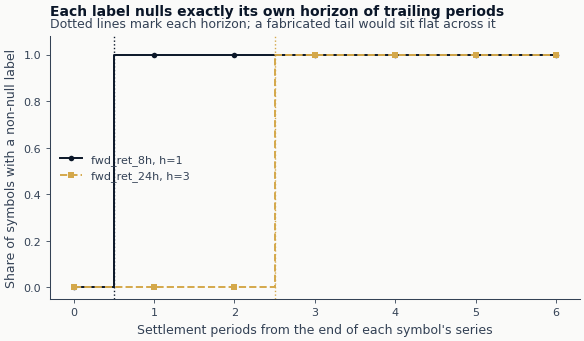

In [9]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(n).is_not_null().mean().alias(n) for n in RETURN_LABELS])
    .sort("from_end")
)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour, fmt in zip(
    RETURN_LABELS, (COLORS["blue"], COLORS["amber"]), ("o-", "s--"), strict=True
):
    label = f"{name}, h={HORIZONS[name]}"
    ax.plot(profile["from_end"], profile[name], fmt, ds="steps-mid", color=colour, label=label)
    ax.axvline(HORIZONS[name] - 0.5, color=colour, linestyle=":", lw=1)
ax.set_xlabel("Settlement periods from the end of each symbol's series")
ax.set_ylabel("Share of symbols with a non-null label")
ax.set_ylim(-0.05, 1.08)
note = "Dotted lines mark each horizon; a fabricated tail would sit flat across it"
add_message_title(ax, "Each label nulls exactly its own horizon of trailing periods", subtitle=note)
ax.legend(loc="center left", frameon=False)
show_with_alt(fig, "Non-null label rate by position from the end of each series.")

## E. Distribution and base rate

What scale is the label, and does it mean the same thing in every regime? Everything from
here through Section G is computed on the development window only, sealed on the label's
**endpoint** rather than its observation date: a row observed shortly before the holdout
still resolves inside it, so a filter on the observation date looks sealed and is not. The
label files keep every row, because the seal governs what this notebook looks at rather than
what it writes.

In [10]:
dev = {
    name: forward_return(labels_df.drop("_label_end"), horizon, "_check")
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls(name)
    for name, horizon in HORIZONS.items()
}
for name, frame in dev.items():
    print(f"{name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_8h: 66,216 development rows through 2023-12-31 08:00:00+00:00
fwd_ret_24h: 66,040 development rows through 2023-12-30 16:00:00+00:00


Both return labels go on one axis with identical bins and a logarithmic count axis. The
difference that matters is not the width, which two dispersion scalars would carry, but the
shape: the longer horizon puts far more mass past the right edge of the axis than past the left,
which is the asymmetry its skew reports and no table of moments shows. The axis is symmetric and
narrower than either label's range, so the rows outside it are counted on each side below rather
than drawn.

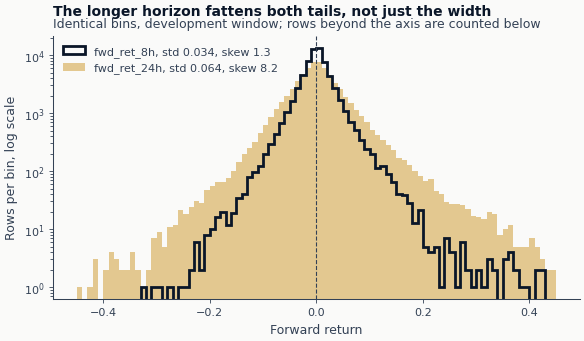

fwd_ret_8h: std 0.03419, skew 1.32, 0 left 4 right of axis
fwd_ret_24h: std 0.06437, skew 8.22, 5 left 46 right of axis


In [11]:
bins = np.linspace(-0.45, 0.45, 91)
styles = {
    VARIANT_LABEL: dict(color=COLORS["amber"], alpha=0.6, zorder=1),
    PRIMARY_LABEL: dict(color=COLORS["blue"], histtype="step", lw=2, zorder=2),
}
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name in (PRIMARY_LABEL, VARIANT_LABEL):
    series = dev[name][name]
    label = f"{name}, std {series.std():.3f}, skew {series.skew():.1f}"
    ax.hist(series.to_numpy(), bins=bins, label=label, **styles[name])
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Forward return")
ax.set_ylabel("Rows per bin, log scale")
note = "Identical bins, development window; rows beyond the axis are counted below"
add_message_title(ax, "The longer horizon fattens both tails, not just the width", subtitle=note)
ax.legend(loc="upper left", frameon=False)
show_with_alt(fig, "Histograms of both labels on identical bins and a log count axis.")

for name in RETURN_LABELS:
    col, series = pl.col(name), dev[name][name]
    lo, hi = dev[name].filter(col < bins[0]).height, dev[name].filter(col > bins[-1]).height
    print(f"{name}: std {series.std():.5f}, skew {series.skew():.2f}, {lo} left {hi} right of axis")

Chapter 7.2 asks for base rates tracked through time, and for a discrete label that means the
class fractions period by period. The cuts here are two constants, so what moves between
years is the volatility of the underlying return, and the middle class absorbs it.

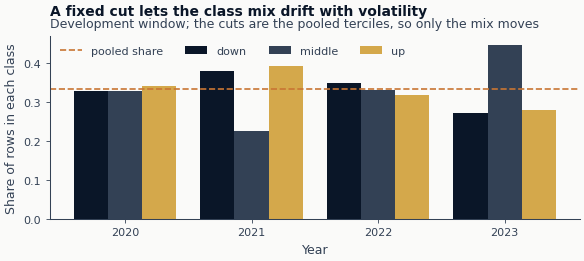

fwd_dir_8h_3c middle share runs 0.227 to 0.448 by year


In [12]:
annual = (
    dev[PRIMARY_LABEL]
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by(["year", THREE_CLASS_LABEL])
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / pl.col("n").sum().over("year")).alias("fraction"))
    .sort("year")
)
years = annual["year"].unique().sort().to_list()
classes = {
    -1: ("down", COLORS["blue"]),
    0: ("middle", COLORS["neutral"]),
    1: ("up", COLORS["amber"]),
}

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
for offset, (cls, (cls_name, colour)) in enumerate(classes.items()):
    rows = annual.filter(pl.col(THREE_CLASS_LABEL) == cls).sort("year")
    x = np.arange(len(years)) + (offset - 1) * 0.27
    ax.bar(x, rows["fraction"].to_numpy(), 0.27, color=colour, label=cls_name)
ax.axhline(1 / 3, color=COLORS["copper"], linestyle="--", lw=1.2, label="pooled share")
ax.set_xticks(np.arange(len(years)), [str(year) for year in years])
ax.set_xlabel("Year")
ax.set_ylabel("Share of rows in each class")
note = "Development window; the cuts are the pooled terciles, so only the mix moves"
add_message_title(ax, "A fixed cut lets the class mix drift with volatility", subtitle=note)
ax.legend(loc="upper left", frameon=False, ncols=4)
show_with_alt(fig, "Class shares of the three-class label, year by year.")

middle = annual.filter(pl.col(THREE_CLASS_LABEL) == 0)["fraction"]
print(f"{THREE_CLASS_LABEL} middle share runs {middle.min():.3f} to {middle.max():.3f} by year")

On the development window the eight-hour label has a standard deviation of 0.03419 and a skew
of 1.32. The twenty-four-hour label is 0.06437 wide, close to the square root of three its
horizon implies, but its skew is 8.22 and the extra mass is one-sided. The three-class label
is balanced over the pooled sample by construction and not within any single year: its middle
class runs from 0.227 of the rows to 0.448 across the four development years.

## F. Overlap and effective sample size

Sampling a multi-period label at every period makes consecutive rows share most of their
forward window, so the row count overstates the evidence. Two measurements answer that in
different units: how fast the overlap decays, and what the rows are worth once it is priced
in. `effective_sample_size` applies Chapter 7.2's average-uniqueness weighting per symbol,
because concurrency is a property of one symbol's own overlapping windows.

The one-period label is the case that checks the measurement rather than the data. Consecutive
one-period forward returns are built from disjoint return intervals, so no row shares any part
of its window with a neighbour, every uniqueness weight must be 1, and the effective count has
to come back equal to the row count. A weighting that counted the anchor bar as consumed would
halve it instead, and would read as a refinement.

Disjoint is not independent, and the figure below is what says so: the one-period label shares
no part of its window with any other row, and its autocorrelation is small but not zero at any
lag drawn. Average uniqueness prices shared windows, not serial dependence, so nothing measured
here discounts the second, and a fold gap sized from the horizon does not either.

Both statistics are counted on `slot`, the settlement each row sits on, so the holes Section D
counts stay holes: a pair enters the autocorrelation only where two settlements are exactly the
lag apart, and a window's uniqueness is weighted over the settlements it actually spans. That is
also why the variant's ratio sits just above 1/h rather than matching it to four decimals - a
hole ends an overlap early, and the rows either side of it keep evidence a fully overlapped
window would have shared away.

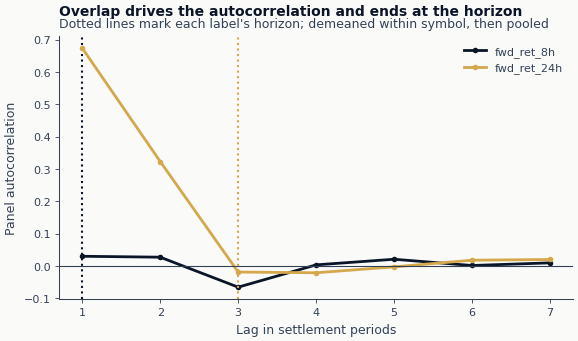

fwd_ret_8h: N=66,216, N_eff=66,216, ratio 1.000 against 1.000 for windows overlapping this fully; autocorrelation 0.030 at lag one, 0.030 at its horizon


fwd_ret_24h: N=66,040, N_eff=22,072, ratio 0.334 against 0.333 for windows overlapping this fully; autocorrelation 0.674 at lag one, -0.019 at its horizon


In [13]:
max_lag = HORIZONS[VARIANT_LABEL] + 4
acf = {n: panel_autocorrelation(dev[n], n, max_lag=max_lag, bar_col="slot") for n in RETURN_LABELS}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in zip(RETURN_LABELS, (COLORS["blue"], COLORS["amber"]), strict=True):
    ax.plot(np.arange(1, max_lag + 1), acf[name], marker="o", color=colour, lw=2, label=name)
    ax.axvline(HORIZONS[name], color=colour, linestyle=":", lw=1.5)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in settlement periods")
ax.set_ylabel("Panel autocorrelation")
note = "Dotted lines mark each label's horizon; demeaned within symbol, then pooled"
add_message_title(ax, "Overlap drives the autocorrelation and ends at the horizon", subtitle=note)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of both labels against lag in periods.")

for name, horizon in HORIZONS.items():
    n_rows, n_eff = effective_sample_size(dev[name], horizon=horizon, bar_col="slot")
    print(
        f"{name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.3f} against "
        f"{1 / horizon:.3f} for windows overlapping this fully; autocorrelation "
        f"{acf[name][0]:.3f} at lag one, {acf[name][horizon - 1]:.3f} at its horizon"
    )

The eight-hour label's 66,216 development rows carry 66,216 effective observations: at a
one-period horizon consecutive windows are disjoint, which is the answer that confirms the
weighting rather than the data. The twenty-four-hour label's 66,040 rows carry 22,072, a ratio
of 0.334 against the 0.333 a fully overlapped three-period window implies, and its
autocorrelation falls from 0.674 at lag one to -0.019 at lag three. The purge gap a fold needs
is set by the forward window itself, not by this count.

## G. Baseline floor

One signal against the primary label on the sealed development window, with no feature
engineering: the rolling z-score of the premium index that `setup.yaml` names as the
treatment, and that `03_financial_features` recomputes under the name `premium_zscore_14d`.
Measuring the floor before building features is what makes a later improvement meaningful.

The information coefficient is the cross-sectional rank correlation at each settlement,
averaged over settlements, which is the quantity a ranking model is scored on. The library
call keeps its output ordered by time, which the standard error depends on. The minimum
cross-section is half the median rather than a bare count, so it means the same thing on a
universe of another size.

The standard error is Newey-West with three lags, one full day of settlements. The horizon
alone would set the bandwidth to zero and apply no correction: the primary label does not
overlap, but its IC series is still serially dependent, because the premium z-score that
produces it moves slowly.

In [14]:
ZSCORE_BARS = 42  # fourteen days, the treatment window setup.yaml declares
premium_col = pl.col("premium_index_close")
centred = premium_col - premium_col.rolling_mean(ZSCORE_BARS).over("symbol")
spread = premium_col.rolling_std(ZSCORE_BARS).over("symbol").clip(lower_bound=1e-8)

baseline = (
    labels_df.sort(["symbol", "timestamp"])
    .with_columns((centred / spread).clip(-10, 10).alias("premium_z"))
    .filter(pl.col("_label_end") < HOLDOUT_START)
    .drop_nulls([PRIMARY_LABEL, "premium_z"])
)
median_cross_section = int(baseline.group_by("timestamp").len()["len"].median())
ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="premium_z",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=median_cross_section // 2,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", maxlags=3)

print(
    f"Baseline: {ZSCORE_BARS}-period premium z-score against {PRIMARY_LABEL}, "
    f"{baseline.height:,} rows, median cross-section {median_cross_section} symbols"
)
print(f"  settlements scored {ic.height:,}, mean IC {stats['mean_ic']:.4f}")
print(
    f"  HAC t {stats['t_stat']:.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3g}"
)

Baseline: 42-period premium z-score against fwd_ret_8h, 65,437 rows, median cross-section 16 symbols
  settlements scored 4,323, mean IC -0.0349
  HAC t -8.10 on 3 Bartlett lags, naive t -8.05, p 6.66e-16


A mean cannot say whether a relationship is present throughout the window or concentrated in
one episode, and only the second would make the floor an artifact of a single regime. Ninety
settlements is thirty days.

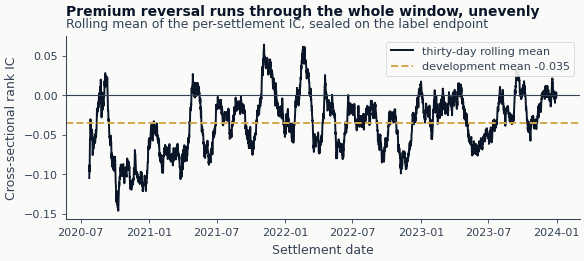

In [15]:
smooth = pl.col("ic").rolling_mean(90, min_samples=30).alias("ic_30d")
rolling_ic = ic.with_columns(smooth).drop_nulls("ic_30d")
mean_ic = stats["mean_ic"]

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.plot(
    rolling_ic["timestamp"].to_list(),
    rolling_ic["ic_30d"].to_numpy(),
    color=COLORS["blue"],
    label="thirty-day rolling mean",
)
ax.axhline(mean_ic, color=COLORS["amber"], linestyle="--", label=f"development mean {mean_ic:+.3f}")
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Settlement date")
ax.set_ylabel("Cross-sectional rank IC")
note = "Rolling mean of the per-settlement IC, sealed on the label endpoint"
add_message_title(ax, "Premium reversal runs through the whole window, unevenly", subtitle=note)
ax.legend(loc="upper right", frameon=True, framealpha=0.9)
show_with_alt(fig, "Rolling mean of the per-settlement rank IC over the window.")

The premium z-score earns a mean IC of -0.0349 against the eight-hour label, negative as a
reversal signal implies. Under the naive standard error that is a t-statistic of -8.05; with
three Newey-West lags it is -8.10, and the two agree because the correction is small at this
bandwidth. That -0.0349 is the floor a feature has to clear, measured on a universe whose median
cross-section is 16 symbols.

## H. Artifacts and the audit record

Each label is written with a digest sidecar beside it, recording the content digest of the
values written, the row count, the key columns, the notebook that wrote it, and the digest of
the price data it was built from. That last field is what ties a label to its data vintage.

The folds that train models are derived per label by `case_studies/utils/cv_window.py` from
`config/setup.yaml` and the timeline of the label parquet written here, so which rows land in
these files is what sets where the fold boundaries fall.

In [16]:
for name in ALL_LABELS:
    record = write_artifact(
        labels_df.select(["timestamp", "symbol", name]).drop_nulls(),
        LABELS_DIR / f"{name}.parquet",
        keys=["timestamp", "symbol"],
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_8h.parquet: 107,673 rows, digest 4262eaab49b41796
fwd_ret_24h.parquet: 107,497 rows, digest 850303e38794f3ea


fwd_dir_8h.parquet: 107,673 rows, digest 84b04ab892dc7744
fwd_dir_8h_3c.parquet: 107,673 rows, digest 8c44efecf60a543c


The record Chapter 7.2 requires to close a label definition, one row per label, built from the
values computed above rather than written by hand.

In [17]:
base_rates = {
    PRIMARY_LABEL: f"mean {dev[PRIMARY_LABEL][PRIMARY_LABEL].mean():+.5f}",
    VARIANT_LABEL: f"mean {dev[VARIANT_LABEL][VARIANT_LABEL].mean():+.5f}",
    BINARY_LABEL: f"up share {dev[PRIMARY_LABEL][BINARY_LABEL].mean():.4f}",
    THREE_CLASS_LABEL: f"cut at {p33:.6f} and {p67:.6f} on the pooled development sample",
}
readers = dict.fromkeys(ALL_LABELS, "the model stages, as a variant declared in `setup.yaml`")
readers[PRIMARY_LABEL] = "03_financial_features.py, as `labels.primary`"
print("\nLabel audit record")
for name, base in base_rates.items():
    horizon = HORIZONS.get(name, HORIZONS[PRIMARY_LABEL])
    print(
        f"\n{name}\n  anchor       perpetual close of the bar completing at t"
        f"\n  horizon      {horizon} settlement periods, {horizon * BAR_HOURS} hours"
        f"\n  resolution   fixed at t+h; a timestamp names the boundary at which its own bar"
        f"\n               closed, so no intraday tie-break arises"
        f"\n  overlap      {horizon - 1} periods shared by consecutive rows"
        f"\n  base rate    {base}\n  consumed by  {readers[name]}"
    )


Label audit record

fwd_ret_8h
  anchor       perpetual close of the bar completing at t
  horizon      1 settlement periods, 8 hours
  resolution   fixed at t+h; a timestamp names the boundary at which its own bar
               closed, so no intraday tie-break arises
  overlap      0 periods shared by consecutive rows
  base rate    mean +0.00099
  consumed by  03_financial_features.py, as `labels.primary`

fwd_ret_24h
  anchor       perpetual close of the bar completing at t
  horizon      3 settlement periods, 24 hours
  resolution   fixed at t+h; a timestamp names the boundary at which its own bar
               closed, so no intraday tie-break arises
  overlap      2 periods shared by consecutive rows
  base rate    mean +0.00302
  consumed by  the model stages, as a variant declared in `setup.yaml`

fwd_dir_8h
  anchor       perpetual close of the bar completing at t
  horizon      1 settlement periods, 8 hours
  resolution   fixed at t+h; a timestamp names the boundary at whic

## Key takeaways

1. **Put the provider's timestamps on the clock at which the data is known, before anything
   else.** A bar stamped with its open time carries a return you could not have traded, and
   every shift after that inherits the error.
2. **Check the forward window with assertions, and account for every row that has no label.**
   An incomplete window, a hole in the grid, a missing price and a label crossing a symbol
   boundary each fail without raising an error and leave plausible numbers behind, so a
   reconciliation that has to balance catches what an eye passing over a row count does not.
3. **Seal a diagnostic on the label's endpoint.** A row observed before the holdout whose
   outcome resolves inside it is a holdout row, so the usable boundary is the boundary minus
   the horizon, counted on the market's own grid.
4. **A row count overstates the evidence when forward windows overlap, and the effective
   count says by how much.** Check the measurement at a horizon whose answer is known by
   inspection: consecutive one-period returns are disjoint, so the effective count has to come
   back equal to the row count, and a weighting that counts the anchor bar halves it instead.
5. **Measure the floor on the signal the hypothesis names, under a standard error that prices
   in the overlap.** A naive t-statistic on a serially dependent IC series treats correlated
   settlements as independent evidence.

**Known limitations.** The label is a price return and not a funding cash flow, so nothing
here measures a carry strategy. The universe is a fixed nineteen-symbol panel rather than a
point-in-time liquidity ranking. The three-class cuts are two constants fitted to the whole
development sample, which the year-by-year figure in Section E makes visible; a calibration
estimated inside each training fold would change which rows fall in which class, and this
notebook does not make that change. The baseline is one signal at one lookback.

**Next**: `03_financial_features.py` assembles the trainable panel and evaluates engineered
features against these labels; `04_model_based_features.py` adds GJR-GARCH and HMM regime
features.